## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [4]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46119,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34781,Total threads: 4
Dashboard: http://127.0.0.1:43249/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:36919,


2025-12-08 15:19:51,996 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:45071' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-76c7f85df6e78f86fdb7ff7d222353ea', 0)} (stimulus_id='handle-worker-cleanup-1765203591.9962735')


In [32]:
client.close()

In [5]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


In [6]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

In [11]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

In [12]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))

In [13]:
lev_19 = ds_19["lev"]
weighted_lev_19 = np.cos(np.deg2rad(lev_19))
lev_19_c = ds_19_c["lev"]
weighted_lev_19_c = np.cos(np.deg2rad(lev_19_c))
lev_22 = ds_22["lev"]
weighted_lev_22 = np.cos(np.deg2rad(lev_22))
lev_24 = ds_24["lev"]
weighted_lev_24 = np.cos(np.deg2rad(lev_24))
lev_1825 = ds_1825["lev"]
weighted_lev_1825 = np.cos(np.deg2rad(lev_1825))

In [42]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01

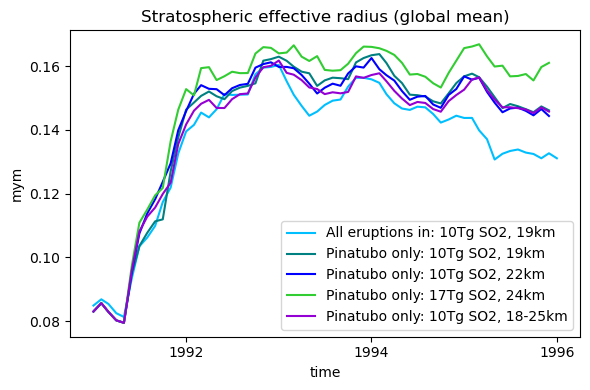

In [43]:
cm_to_mym = 10000
p_lev = 20

SReff = ds_19["REFF_AERO"].where(ds_19["lev"] < p_lev_19)
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.weighted(weighted_lev_19).mean(dim="lev")
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].where(ds_19_c["lev"] < p_lev_19_c)
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym
SReff_19_c = SReff_19_c.weighted(weighted_lev_19_c).mean(dim="lev")

SReff_22 = ds_22["REFF_AERO"].where(ds_22["lev"] < p_lev_22)
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym
SReff_22 = SReff_22.weighted(weighted_lev_22).mean(dim="lev")

SReff_24 = ds_24["REFF_AERO"].where(ds_24["lev"] < p_lev_24)
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym
SReff_24 = SReff_24.weighted(weighted_lev_24).mean(dim="lev")

SReff_1825 = ds_1825["REFF_AERO"].where(ds_1825["lev"] < p_lev_1825)
SReff_1825 = SReff_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])*cm_to_mym
SReff_1825 = SReff_1825.weighted(weighted_lev_1825).mean(dim="lev")

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(color = "darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (global mean)")
plt.legend()
plt.tight_layout()

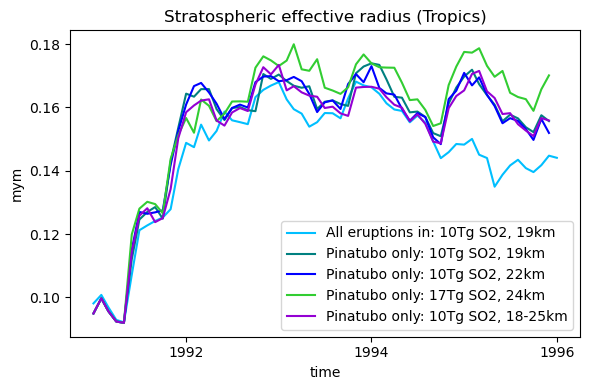

In [46]:
cm_to_mym = 10000
p_lev_l = 50
p_lev_u = 20

SReff = ds_19["REFF_AERO"].where(ds_19["lev"]< p_lev_19)
SReff = SReff.sel(lat = slice(-20,20))
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.weighted(weighted_lev_19).mean(dim="lev")
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].where(ds_19_c["lev"]< p_lev_19_c)
SReff_19_c = SReff_19_c.sel(lat = slice(-20,20))
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym
SReff_19_c = SReff_19_c.weighted(weighted_lev_19_c).mean(dim="lev")

SReff_22 = ds_22["REFF_AERO"].where(ds_22["lev"]< p_lev_22)
SReff_22 = SReff_22.sel(lat = slice(-20,20))
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym
SReff_22 = SReff_22.weighted(weighted_lev_22).mean(dim="lev")

SReff_24 = ds_24["REFF_AERO"].where(ds_24["lev"]< p_lev_24)
SReff_24 = SReff_24.sel(lat = slice(-20,20))
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym
SReff_24 = SReff_24.weighted(weighted_lev_24).mean(dim="lev")

SReff_1825 = ds_1825["REFF_AERO"].where(ds_1825["lev"]< p_lev_1825)
SReff_1825 = SReff_1825.sel(lat = slice(-20,20))
SReff_1825 = SReff_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])*cm_to_mym
SReff_1825 = SReff_1825.weighted(weighted_lev_1825).mean(dim="lev")


plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(color = "darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.ylabel("mym")
plt.title(f"Stratospheric effective radius (Tropics)")
plt.legend()
plt.tight_layout()


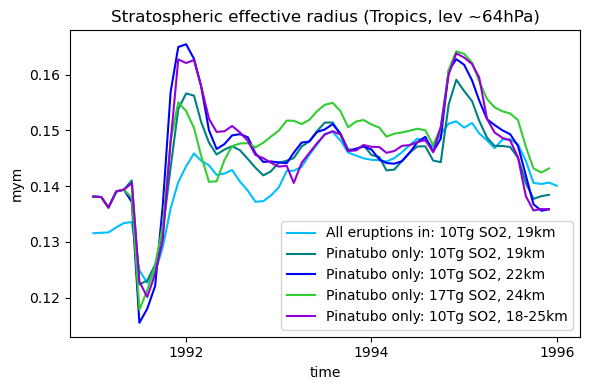

In [51]:
cm_to_mym = 10000
p_lev = 64

SReff = ds_19["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff = SReff.sel(lat = slice(-5, 5))
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].sel(lev = p_lev, method = "nearest")
SReff_19_c = SReff_19_c.sel(lat = slice(-5, 5))
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym

SReff_22 = ds_22["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_22 = SReff_22.sel(lat = slice(-5, 5))
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym

SReff_24 = ds_24["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_24 = SReff_24.sel(lat = slice(-5, 5))
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym

SReff_1825 = ds_1825["REFF_AERO"].sel(lev = p_lev, method="nearest")
SReff_1825 = SReff_1825.sel(lat = slice(-5, 5))
SReff_1825 = SReff_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])*cm_to_mym

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(color = "darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (Tropics, lev ~64hPa)")
plt.legend()
plt.tight_layout()

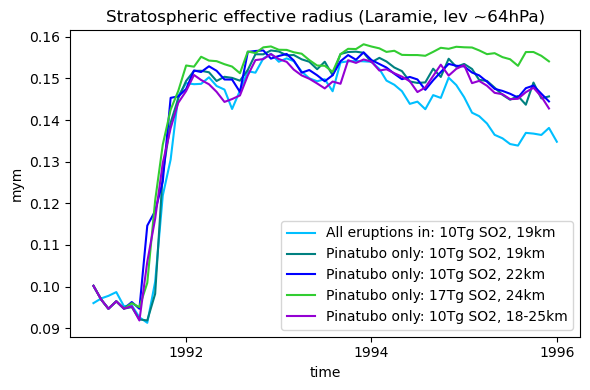

In [53]:
p_lev_l = 130
p_lev_u = 10
p_lev=64
SReff = ds_19["REFF_AERO"].where(ds_19["lev"]< p_lev)
SReff = SReff.sel(lat = slice(40, 43))
SReff = SReff.sel(lon = slice(105, 106.5))
SReff = SReff.weighted(weighted_lat_19).mean(dim=["lat", "lon"])*cm_to_mym
SReff = SReff.weighted(weighted_lev_19).mean(dim="lev")
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))

SReff_19_c = ds_19_c["REFF_AERO"].where(ds_19_c["lev"]< p_lev)
SReff_19_c = SReff_19_c.sel(lat = slice(40, 43))
SReff_19_c = SReff_19_c.sel(lon = slice(105, 106.5))
SReff_19_c = SReff_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])*cm_to_mym
SReff_19_c = SReff_19_c.weighted(weighted_lev_19_c).mean(dim="lev")

SReff_22 = ds_22["REFF_AERO"].where(ds_22["lev"]< p_lev)
SReff_22 = SReff_22.sel(lat = slice(40, 43))
SReff_22 = SReff_22.sel(lon = slice(105, 106.5))
SReff_22 = SReff_22.weighted(weighted_lat_22).mean(dim=["lat", "lon"])*cm_to_mym
SReff_22 = SReff_22.weighted(weighted_lev_22).mean(dim="lev")

SReff_24 = ds_24["REFF_AERO"].where(ds_24["lev"]< p_lev)
SReff_24 = SReff_24.sel(lat = slice(40, 43))
SReff_24 = SReff_24.sel(lon = slice(105, 106.5))
SReff_24 = SReff_24.weighted(weighted_lat_24).mean(dim=["lat", "lon"])*cm_to_mym
SReff_24 = SReff_24.weighted(weighted_lev_24).mean(dim="lev")

SReff_1825 = ds_1825["REFF_AERO"].where(ds_1825["lev"]< p_lev)
SReff_1825 = SReff_1825.sel(lat = slice(40, 43))
SReff_1825 = SReff_1825.sel(lon = slice(105, 106.5))
SReff_1825 = SReff_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])*cm_to_mym
SReff_1825 = SReff_1825.weighted(weighted_lev_1825).mean(dim="lev")

plt.figure(figsize=(6, 4))
SReff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
SReff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
SReff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
SReff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
SReff_1825.plot(color = "darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.ylabel("mym")
plt.title(f"Stratospheric effective radius (Laramie, lev ~{p_lev}hPa)")
plt.legend()
plt.tight_layout()

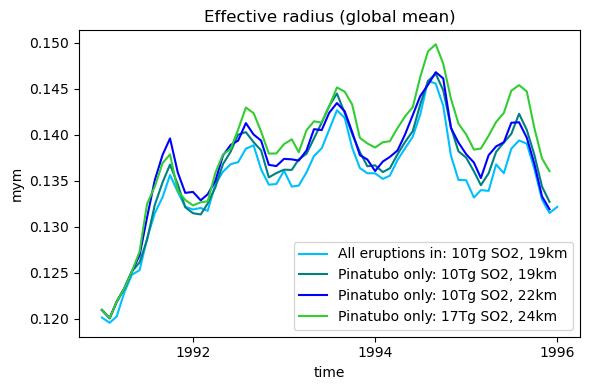

In [14]:
Reff = ds_19["REFF_AERO"].weighted(weighted_lat_19).mean(dim=["lat", "lon", "lev"])*cm_to_mym
Reff = Reff.sel(time=slice("1991-01-01", "1996-01-01"))


Reff_19_c = ds_19_c["REFF_AERO"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])*cm_to_mym

Reff_22 = ds_22["REFF_AERO"].weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])*cm_to_mym

Reff_24 = ds_24["REFF_AERO"].weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])*cm_to_mym

plt.figure(figsize=(6, 4))
Reff.plot(color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
Reff_19_c.plot(color = "teal", label = "Pinatubo only: 10Tg SO2, 19km")
Reff_22.plot(color = "blue", label = "Pinatubo only: 10Tg SO2, 22km")
Reff_24.plot(color = "limegreen", label = "Pinatubo only: 17Tg SO2, 24km")
plt.ylabel("mym")
plt.title("Effective radius (global mean)")
plt.legend()
plt.tight_layout()

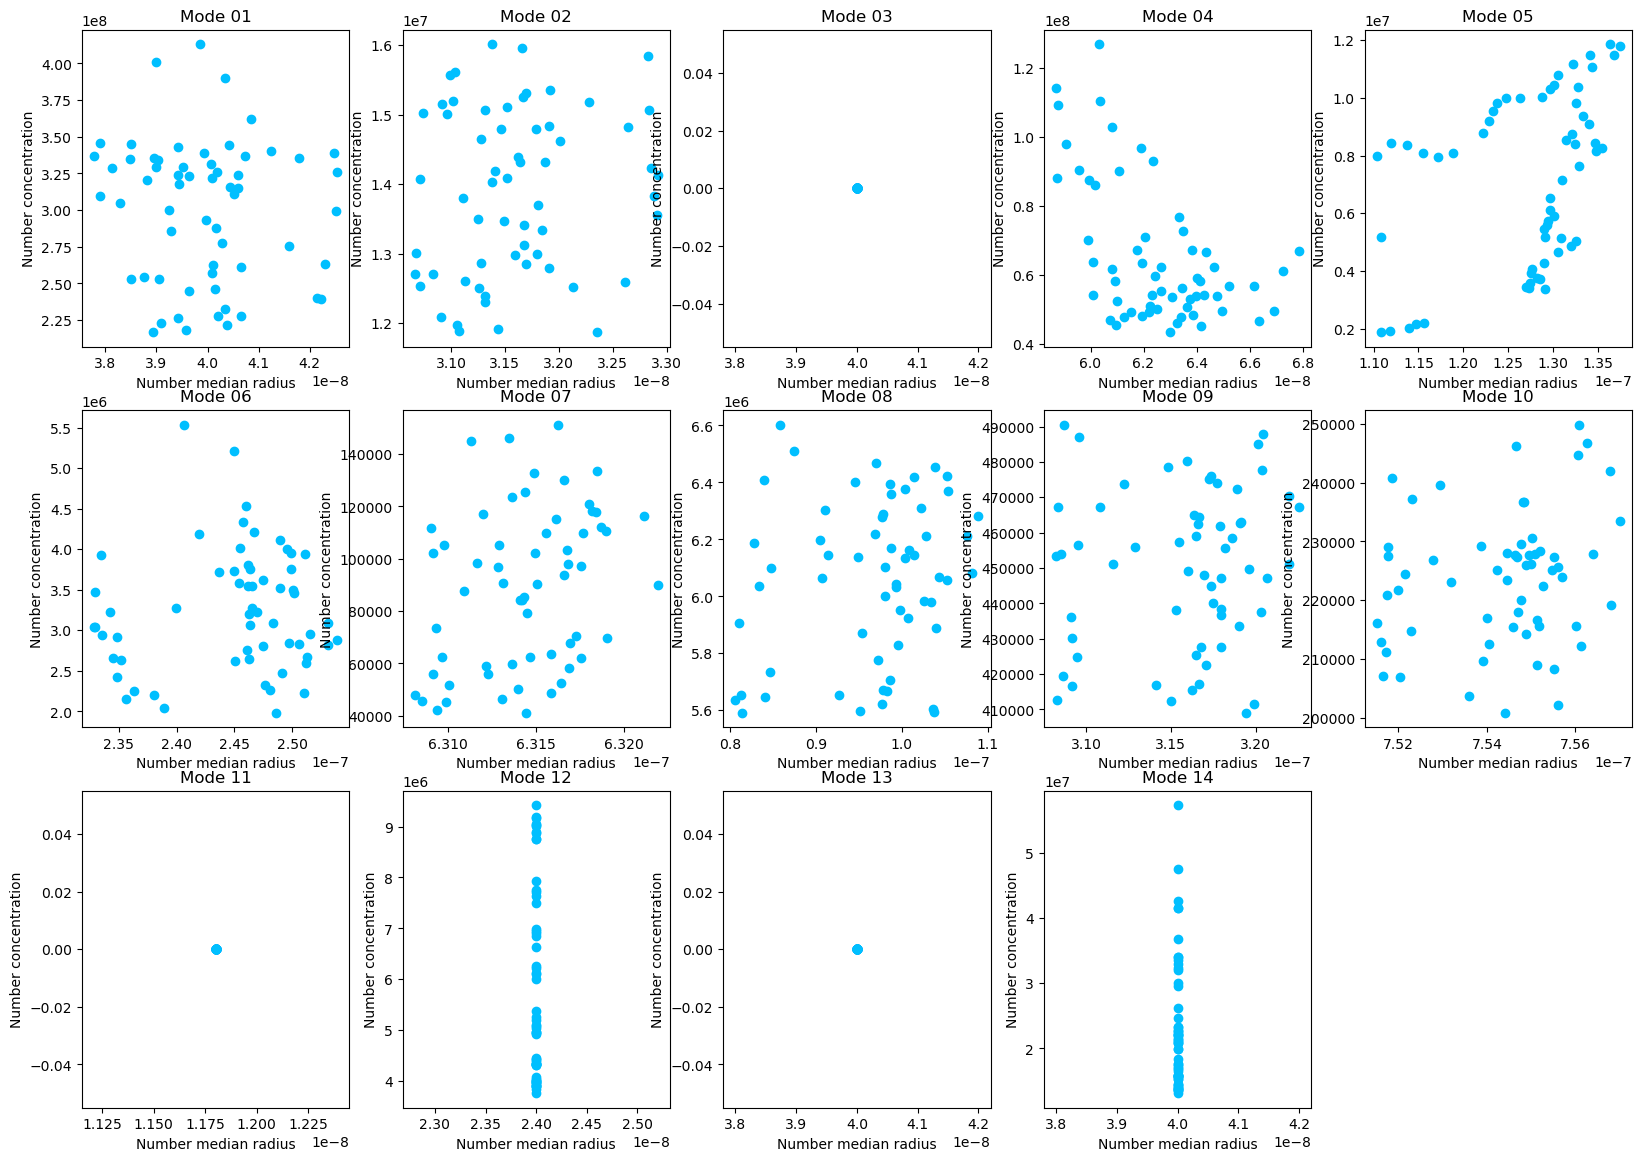

In [ ]:
# vars to use: NMR, SIGMA, NCONC, VCONC, NNAT_
mode_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12", "13", "14"]

fig, axes = plt.subplots(3, 5, figsize=(20, 14), sharex=False, sharey=False)
axes = axes.flatten() 
for i, mode in enumerate(mode_list):
    nmr_var = f"NMR{mode}"
    nconc_var = f"NCONC{mode}"
    
    nmr = ds_19_c[nmr_var].weighted(weighted_lat_19_c).mean(dim=["lat","lon","lev"])
    nconc = ds_19_c[nconc_var].weighted(weighted_lat_19_c).mean(dim=["lat","lon","lev"])
    
    axes[i].scatter(nmr, nconc, color="deepskyblue")
    axes[i].set_xlabel("Number median radius")
    axes[i].set_ylabel("Number concentration")
    axes[i].set_title(f"Mode {mode}")

for j in range(i+1, 3*5):
    fig.delaxes(axes[j])

plt.show()